## STROKE PREDICTION MODEL (Machine Learning)

In this part, I will select the features for machine learning :
- bmi : remove outliers and fill missing values 
- remove the row gender = other
- remove the column id 
- transform columns with categorical features with get dummies: gender, ever_married, work_type, smoking_status 

## 1.Import Libraries

In [64]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2.Load Data

In [67]:
df = pd.read_csv("df_preprocessed.csv", sep=";")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [69]:
df['bmi'].min()

10.3

## 3.Feature Engineering

### Bmi

Remove outliers and fill the missing bmi 

Dataset shape after: (4936, 12)
Stroke cases preserved: 249
BMI range before: 10.3 - 97.6
BMI range after: 10.3 - 59.7


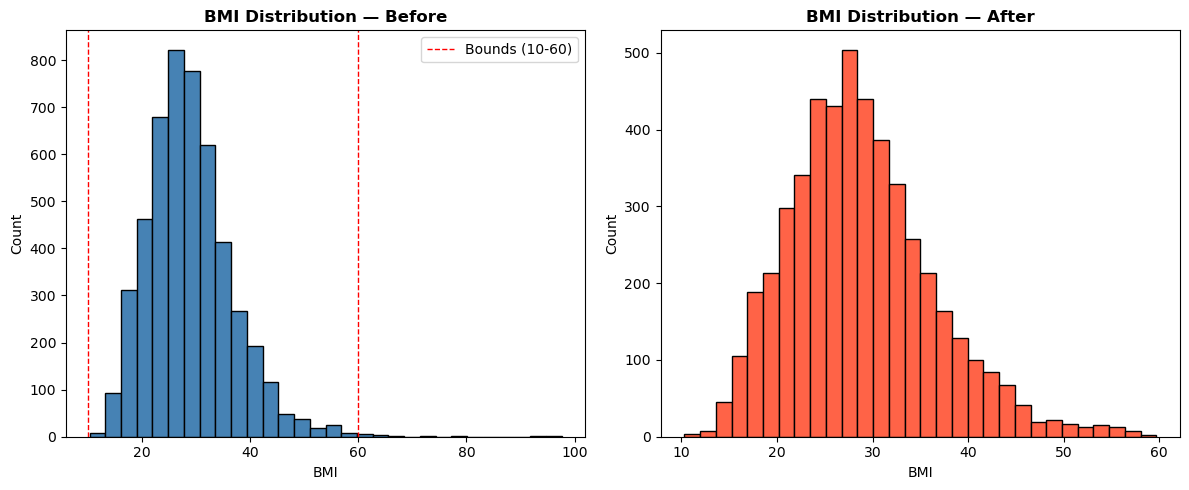

In [74]:
# Save original BMI before removing outliers
bmi_before = df['bmi'].copy()

# Remove BMI outliers only for non-stroke cases and extreme values higher than 60 
stroke_cases = df[df['stroke'] == 1]
no_stroke_cases = df[df['stroke'] == 0]
no_stroke_clean = no_stroke_cases[(no_stroke_cases['bmi'] <= 60)]
df = pd.concat([no_stroke_clean, stroke_cases]).reset_index(drop=True)

print(f"Dataset shape after: {df.shape}")
print(f"Stroke cases preserved: {df['stroke'].sum()}")
print(f"BMI range before: {bmi_before.min():.1f} - {bmi_before.max():.1f}")
print(f"BMI range after: {bmi_before.min():.1f} - {df['bmi'].max():.1f}")

# Plot before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
axes[0].hist(bmi_before.dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('BMI Distribution — Before', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=1, label='Bounds (10-60)')
axes[0].axvline(x=60, color='red', linestyle='--', linewidth=1)
axes[0].legend()

# After
axes[1].hist(df['bmi'].dropna(), bins=30, color='tomato', edgecolor='black')
axes[1].set_title('BMI Distribution — After', fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

BMI outliers were removed only from non-stroke cases to preserve all positive stroke cases, as they are rare and valuable given the strong class imbalance in the dataset

In [77]:
# bmi 
print(f"Missing BMI before: {df['bmi'].isna().sum()}")
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print(f"Missing BMI after: {df['bmi'].isna().sum()}")
print(f"Median BMI used for imputation: {df['bmi'].median():.2f}")


Missing BMI before: 40
Missing BMI after: 0
Median BMI used for imputation: 28.00


I decided here to fill the bmi with median, as it's robust and won't be pulled by extreme values   
Mode is more compatible with categorical value (most representated values) and mean when the distribution is not skewed and followed normal distribution.

Missing bmi values were imputed after outlier removal to ensure the median was not influenced by extreme values

##### Gender

In [82]:
# Drop 'Other' in gender as it has only 1 case without stroke
df = df[df['gender'] != 'Other']

##### Id

In [85]:
# Drop non-relevant features, id (index) and residence_type
df.drop(columns=['id', 'Residence_type'], inplace=True)

##### Categorical Features 

In [88]:
# One-hot encode all categorical features (binary + multi-category)
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'smoking_status'], drop_first=True).astype(int)

In [90]:
#final dataset
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values: {df.isna().sum().sum()}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (4935, 15)

Data types:
age                               int32
hypertension                      int32
heart_disease                     int32
avg_glucose_level                 int32
bmi                               int32
stroke                            int32
gender_Male                       int32
ever_married_Yes                  int32
work_type_Never_worked            int32
work_type_Private                 int32
work_type_Self-employed           int32
work_type_children                int32
smoking_status_formerly smoked    int32
smoking_status_never smoked       int32
smoking_status_smokes             int32
dtype: object

Missing values: 0

Columns:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

First rows:
   age  hyper

In [94]:
# save the new df

df.to_csv('C:/Users/EmilieBoone/Desktop/DSTI/PythonLabs/PythonLabs_ML_Boone/df_preprocessed.csv',sep=";", index=False)
print(f"Dataset saved — shape: {df.shape}")

Dataset saved — shape: (4935, 15)


Features were engineered and the dataset is now ready for machine learning.
A supervised classification approach will be used,as ground truth labels are available.
The main limitation of this dataset is class imbalance. Stroke cases represent a small minority of the data, which can bias models towards the majority class (non stroke).
To improve prediction performance, adressing this imbalance with the following strategies:
- Oversampling the minority class (SMOTE) 
- Undersampling the majority class
- Class weight adjustement (class_weight='balanced')
- collecting more real stroke cases from other datasets